In [5]:
import os
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score)

SAVE_PATH = r"D:\Stress Detection\data"

X      = np.load(os.path.join(SAVE_PATH, 'X_scaled.npy'))
y      = np.load(os.path.join(SAVE_PATH, 'y.npy'))
subs   = np.load(os.path.join(SAVE_PATH, 'subjects.npy'))

print(f"X shape    : {X.shape}")
print(f"y shape    : {y.shape}")
print(f"Subjects   : {np.unique(subs)}")
print(f"Stress %   : {np.mean(y==1)*100:.1f}%")

X shape    : (6569, 66)
y shape    : (6569,)
Subjects   : ['S10' 'S11' 'S13' 'S14' 'S15' 'S16' 'S17' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7'
 'S8' 'S9']
Stress %   : 30.0%


In [6]:
# ── Leave-One-Subject-Out (LOSO) ─────────────────────────────────────────────
# Why LOSO? — prevents data leakage between same subject's windows
# Each fold: 1 subject = test, remaining 14 = train

def get_models():
    return {
        'SVM': SVC(
            kernel='rbf', C=1.0, gamma='scale',
            probability=True, random_state=42
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, min_samples_leaf=5, random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=15,
            min_samples_leaf=3, random_state=42, n_jobs=-1
        ),
        'ANN': MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500, random_state=42,
            early_stopping=True, validation_fraction=0.1
        ),
    }

unique_subjects = np.unique(subs)
model_names     = ['SVM', 'Decision Tree', 'Random Forest', 'ANN']

# Store per-fold results
fold_results = {m: [] for m in model_names}
all_preds    = {m: np.zeros_like(y) for m in model_names}

print("Starting LOSO cross-validation...")
print(f"Total folds: {len(unique_subjects)}\n")

for fold_idx, test_subject in enumerate(unique_subjects):
    train_mask = subs != test_subject
    test_mask  = subs == test_subject

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    models = get_models()

    fold_row = {'Subject': test_subject}

    for m_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds) * 100
        f1  = f1_score(y_test, preds, average='macro', zero_division=0)

        fold_row[f'{m_name}_acc'] = round(acc, 1)
        fold_row[f'{m_name}_f1']  = round(f1, 3)

        all_preds[m_name][test_mask] = preds

    fold_results_list = fold_results.get('_rows', [])
    fold_results['_rows'] = fold_results_list + [fold_row]

    print(f"  Fold {fold_idx+1:2d} | Test: {test_subject} | "
          f"RF acc: {fold_row['Random Forest_acc']:.1f}% | "
          f"SVM acc: {fold_row['SVM_acc']:.1f}%")

print("\nLOSO complete.")

Starting LOSO cross-validation...
Total folds: 15

  Fold  1 | Test: S10 | RF acc: 78.7% | SVM acc: 92.9%
  Fold  2 | Test: S11 | RF acc: 91.8% | SVM acc: 95.2%
  Fold  3 | Test: S13 | RF acc: 85.7% | SVM acc: 91.4%
  Fold  4 | Test: S14 | RF acc: 94.8% | SVM acc: 96.8%
  Fold  5 | Test: S15 | RF acc: 82.0% | SVM acc: 77.9%
  Fold  6 | Test: S16 | RF acc: 99.3% | SVM acc: 91.4%
  Fold  7 | Test: S17 | RF acc: 93.3% | SVM acc: 96.7%
  Fold  8 | Test: S2 | RF acc: 73.2% | SVM acc: 71.3%
  Fold  9 | Test: S3 | RF acc: 89.5% | SVM acc: 74.2%
  Fold 10 | Test: S4 | RF acc: 71.9% | SVM acc: 71.2%
  Fold 11 | Test: S5 | RF acc: 95.4% | SVM acc: 95.0%
  Fold 12 | Test: S6 | RF acc: 87.8% | SVM acc: 96.6%
  Fold 13 | Test: S7 | RF acc: 58.7% | SVM acc: 52.8%
  Fold 14 | Test: S8 | RF acc: 94.7% | SVM acc: 83.3%
  Fold 15 | Test: S9 | RF acc: 82.3% | SVM acc: 77.0%

LOSO complete.



LOSO RESULTS — PER FOLD
Subject  SVM_acc  SVM_f1  Decision Tree_acc  Decision Tree_f1  Random Forest_acc  Random Forest_f1  ANN_acc  ANN_f1
    S10     92.9   0.922               72.4             0.538               78.7             0.680     72.4   0.722
    S11     95.2   0.946               83.9             0.827               91.8             0.909     91.2   0.903
    S13     91.4   0.899               63.3             0.521               85.7             0.809     83.4   0.821
    S14     96.8   0.963               83.3             0.824               94.8             0.941     96.8   0.963
    S15     77.9   0.656               80.2             0.703               82.0             0.734     82.7   0.756
    S16     91.4   0.905               94.8             0.939               99.3             0.992     94.3   0.936
    S17     96.7   0.962               73.2             0.607               93.3             0.920     98.0   0.977
     S2     71.3   0.432               58.9    

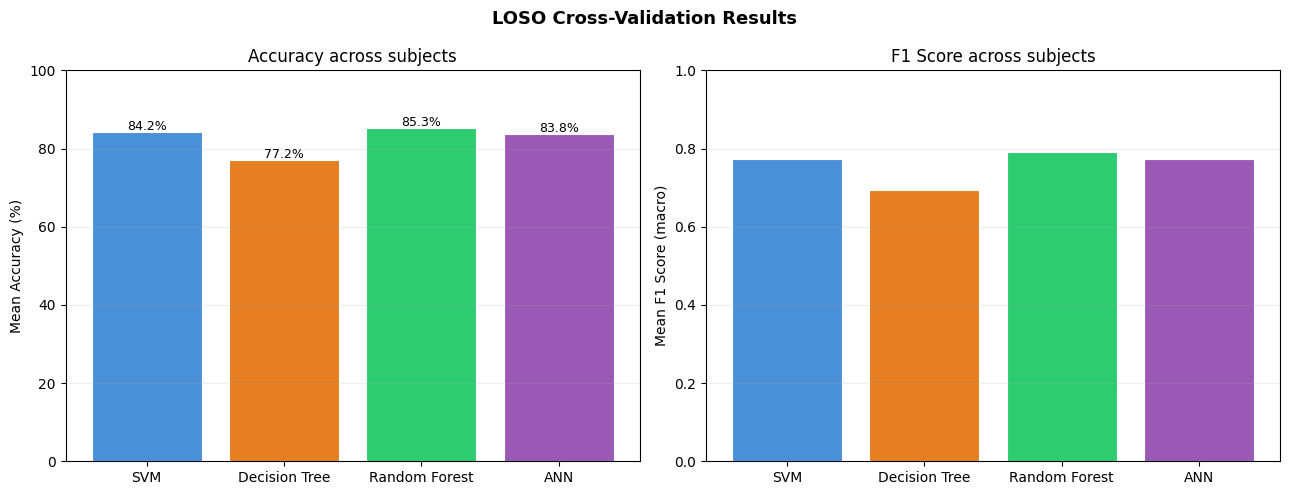

In [7]:
import matplotlib.pyplot as plt

rows = fold_results['_rows']
results_df = pd.DataFrame(rows)

print("\n" + "="*70)
print("LOSO RESULTS — PER FOLD")
print("="*70)
print(results_df.to_string(index=False))

# ── Mean across folds ────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MEAN ACROSS ALL FOLDS")
print("="*70)

summary = {}
for m in model_names:
    acc_col = f'{m}_acc'
    f1_col  = f'{m}_f1'
    summary[m] = {
        'Mean Accuracy (%)': round(results_df[acc_col].mean(), 2),
        'Std Accuracy':      round(results_df[acc_col].std(),  2),
        'Mean F1 (macro)':   round(results_df[f1_col].mean(),  3),
    }

summary_df = pd.DataFrame(summary).T
print(summary_df.to_string())

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LOSO Cross-Validation Results', fontsize=13, fontweight='bold')

colors = ['#4a90d9','#e67e22','#2ecc71','#9b59b6']

axes[0].bar(summary_df.index, summary_df['Mean Accuracy (%)'],
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylabel('Mean Accuracy (%)')
axes[0].set_title('Accuracy across subjects')
axes[0].set_ylim(0, 100)
for i, (idx, row) in enumerate(summary_df.iterrows()):
    axes[0].text(i, row['Mean Accuracy (%)']+0.5,
                 f"{row['Mean Accuracy (%)']:.1f}%", ha='center', fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

axes[1].bar(summary_df.index, summary_df['Mean F1 (macro)'],
            color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_ylabel('Mean F1 Score (macro)')
axes[1].set_title('F1 Score across subjects')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'loso_results.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# ── Best model = Random Forest (typically best on WESAD) ────────────────────
# Train on ALL subjects for deployment

print("Training final models on full dataset...")

final_models = get_models()
for m_name, model in final_models.items():
    model.fit(X, y)
    print(f"  {m_name} trained.")

# Save all 4 models
for m_name, model in final_models.items():
    fname = m_name.lower().replace(' ', '_') + '_model.pkl'
    joblib.dump(model, os.path.join(SAVE_PATH, fname))
    print(f"  saved {fname}")

print(f"\nNB03 complete ✓  →  proceed to NB04")

Training final models on full dataset...
  SVM trained.
  Decision Tree trained.
  Random Forest trained.
  ANN trained.
  saved svm_model.pkl
  saved decision_tree_model.pkl
  saved random_forest_model.pkl
  saved ann_model.pkl

NB03 complete ✓  →  proceed to NB04
